# Residual Learning for Age Prediction

**Strategy** : Inspirée des architectures gagnantes du *Biomarkers of Aging Challenge* (SITH & ResNet).

| Étape | Description |
|-------|------------|
| 1 | **Base Model** — `ElasticNetCV` produit une prédiction linéaire $P_{\text{lin}}$ |
| 2 | **Résidus** — $R = \text{Age}_{\text{réel}} - P_{\text{lin}}$ |
| 3 | **Non-Linear Booster** — XGBoost apprend à prédire $R$ à partir des mêmes CpGs |
| 4 | **Bias Correction** — Régression linéaire finale sur $(P_{\text{lin}}, \hat{R})$ pour corriger le biais systématique |

**Validation** : Nested Cross-Validation (5 outer × 5 inner folds) pour garantir l'absence de surapprentissage.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
from time import time

from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

from data.data_loader import load_annotations, load_cpg_names, load_selected_cpgs
from features.selection import select_top_k_cpgs

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports OK")

Imports OK


## 1. Chargement des données

In [2]:
DATA_DIR = Path("Data")
TOP_K = 5000
CHUNK_SIZE = 2000

# Annotations
annot = load_annotations(DATA_DIR)
sample_ids = annot.index.tolist()
y_all = annot["age"].values.astype(np.float64)

# CpG names
cpg_names = load_cpg_names(DATA_DIR)

print(f"Samples : {len(sample_ids)}")
print(f"CpG sites : {len(cpg_names):,}")
print(f"Age range : {y_all.min():.0f} – {y_all.max():.0f} ans")

2026-02-11 18:37:47 - src.data.data_loader - INFO - Loading annotations from Data/annot_projet.csv
2026-02-11 18:37:47 - src.data.data_loader - INFO - Loaded 400 samples
2026-02-11 18:37:47 - src.data.data_loader - INFO - Loading CpG names from Data/cpg_names_projet.csv
2026-02-11 18:37:47 - src.data.data_loader - INFO - Loaded 894006 CpG sites
Samples : 400
CpG sites : 894,006
Age range : 18 – 90 ans


## 2. Sélection de features (sur l'ensemble complet, resélectionnée par fold)

Pour la nested CV, la sélection de features doit se faire **à l'intérieur de chaque fold** pour éviter le data leakage. On pré-sélectionne ici un superset large pour accélérer le chargement, puis chaque fold re-sélectionne ses propres top-K.

In [ ]:
# Pré-sélection d'un superset (top 10k) sur tout le dataset pour le chargement
# Chaque fold fera sa propre sélection parmi ces features
SUPERSET_K = 10000

print(f"Sélection du superset de {SUPERSET_K} CpGs les plus corrélés...")
t0 = time()
superset_indices, superset_names = select_top_k_cpgs(
    DATA_DIR / "c_sample.csv",
    sample_ids=sample_ids,
    y=y_all,
    cpg_names=cpg_names,
    top_k=SUPERSET_K,
    chunk_size=CHUNK_SIZE,
)
print(f"Fait en {time() - t0:.0f}s")

# Charger ce superset complet
print(f"Chargement de la matrice {SUPERSET_K} × {len(sample_ids)}...")
t0 = time()
X_full_df = load_selected_cpgs(
    DATA_DIR / "c_sample.csv",
    sample_ids=sample_ids,
    selected_indices=superset_indices,
    selected_names=superset_names,
    chunk_size=CHUNK_SIZE,
)
# Transposer : (samples, features)
X_full = X_full_df.T.values.astype(np.float32)
feature_names = superset_names
print(f"Fait en {time() - t0:.0f}s — Shape: {X_full.shape}")

# Imputation rapide des NaN (médiane par feature)
nan_mask = np.isnan(X_full)
if nan_mask.any():
    col_medians = np.nanmedian(X_full, axis=0)   # à changer par un mice(bayesian...)
    inds = np.where(nan_mask)
    X_full[inds] = col_medians[inds[1]]
    print(f"NaN imputés : {nan_mask.sum():,} valeurs")
else:
    print("Aucun NaN détecté")

Sélection du superset de 10000 CpGs les plus corrélés...
2026-02-11 18:37:47 - src.features.selection - INFO - Selecting top 10000 CpG sites by correlation with age
2026-02-11 18:38:34 - src.features.selection - INFO - Selected 10000 CpG sites with correlation range: 0.4270 to 0.9277
Fait en 46s
Chargement de la matrice 10000 × 400...
2026-02-11 18:38:34 - src.data.data_loader - INFO - Loading 10000 selected CpG sites from Data/c_sample.csv
2026-02-11 18:38:59 - src.data.data_loader - INFO - Loaded shape: (10000, 400)
Fait en 26s — Shape: (400, 10000)
NaN imputés : 54,302 valeurs


## 3. Pipeline de Residual Learning

Chaque composant est encapsulé dans une classe pour permettre la réutilisation dans la nested CV.

In [ ]:
class ResidualLearningPipeline:
    """
    Pipeline hybride : ElasticNet (linéaire) + XGBoost (résidus) + Bias Correction.
    
    Étape 1 : ElasticNetCV → prédiction linéaire P_lin
    Étape 2 : Résidus R = y - P_lin
    Étape 3 : XGBoost sur les features → prédit R_hat
    Étape 4 : LinearRegression sur [P_lin, R_hat] → prédiction finale corrigée
    """
    
    def __init__(
        self,
        # ElasticNet params
        enet_l1_ratios=(0.1, 0.3, 0.5, 0.7, 0.9),
        enet_n_alphas=50,
        enet_cv=5,
        # Feature selection
        top_k=5000,
        # XGBoost params
        xgb_n_estimators=300,
        xgb_max_depth=3,
        xgb_learning_rate=0.03,
        xgb_subsample=0.7,
        xgb_colsample_bytree=0.5,
        xgb_reg_alpha=10.0,
        xgb_reg_lambda=50.0,
        xgb_min_child_weight=10,
        xgb_early_stopping_rounds=30,
    ):
        self.enet_l1_ratios = enet_l1_ratios
        self.enet_n_alphas = enet_n_alphas
        self.enet_cv = enet_cv
        self.top_k = top_k
        
        self.xgb_params = dict(
            n_estimators=xgb_n_estimators,
            max_depth=xgb_max_depth,
            learning_rate=xgb_learning_rate,
            subsample=xgb_subsample,
            colsample_bytree=xgb_colsample_bytree,
            reg_alpha=xgb_reg_alpha,
            reg_lambda=xgb_reg_lambda,
            min_child_weight=xgb_min_child_weight,
            early_stopping_rounds=xgb_early_stopping_rounds,
            objective="reg:squarederror",
            eval_metric="mae",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
        
        # Components (fitted)
        self.feature_idx_ = None  # indices of top-k features within superset
        self.enet_ = None
        self.xgb_ = None
        self.bias_corrector_ = None
    
    def _select_features(self, X_train, y_train):
        """Sélection top-k par corrélation (intra-fold)."""
        corrs = np.array([
            abs(np.corrcoef(X_train[:, j], y_train)[0, 1])
            for j in range(X_train.shape[1])
        ])
        # Gérer les NaN dans les corrélations
        corrs = np.nan_to_num(corrs, nan=0.0)
        k = min(self.top_k, len(corrs))
        self.feature_idx_ = np.argpartition(corrs, -k)[-k:]
        return X_train[:, self.feature_idx_]
    
    def fit(self, X_train, y_train, X_val=None, y_val=None):
        """
        Entraîne le pipeline complet.
        
        Args:
            X_train: (n_samples, n_features) matrice d'entraînement
            y_train: (n_samples,) âges réels
            X_val: validation set pour early stopping XGBoost (optionnel)
            y_val: âges de validation (optionnel)
        """
        # --- Feature selection intra-fold ---
        X_sel = self._select_features(X_train, y_train)
        
        # --- Scaling ---
        X_scaled = X_sel
        
        # --- Étape 1 : ElasticNetCV ---
        self.enet_ = ElasticNetCV(
            l1_ratio=list(self.enet_l1_ratios),
            n_alphas=self.enet_n_alphas,
            cv=self.enet_cv,
            max_iter=50000,
            tol=1e-4,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        self.enet_.fit(X_scaled, y_train)
        P_lin = self.enet_.predict(X_scaled)
        
        # --- Étape 2 : Résidus ---
        residuals = y_train - P_lin
        
        # --- Étape 3 : XGBoost sur résidus ---
        self.xgb_ = XGBRegressor(**self.xgb_params)
        
        fit_params = {}
        if X_val is not None and y_val is not None:
            X_val_sel = X_val[:, self.feature_idx_]
            X_val_scaled = X_val_sel
            P_lin_val = self.enet_.predict(X_val_scaled)
            residuals_val = y_val - P_lin_val
            fit_params["eval_set"] = [(X_val_scaled, residuals_val)]
            fit_params["verbose"] = False
        else:
            # Use training set for early stopping (less ideal but functional)
            fit_params["eval_set"] = [(X_scaled, residuals)]
            fit_params["verbose"] = False
        
        self.xgb_.fit(X_scaled, residuals, **fit_params)
        R_hat = self.xgb_.predict(X_scaled)
        
        # --- Étape 4 : Bias Correction (style ResNet 3ème place) ---
        # Régression linéaire sur [P_lin, R_hat] pour corriger le biais
        meta_features = np.column_stack([P_lin, R_hat])
        self.bias_corrector_ = LinearRegression()
        self.bias_corrector_.fit(meta_features, y_train)
        
        return self
    
    def predict(self, X):
        """Prédiction finale = Bias Correction(P_lin, R_hat)."""
        X_sel = X[:, self.feature_idx_]
        X_scaled = X_sel
        
        P_lin = self.enet_.predict(X_scaled)
        R_hat = self.xgb_.predict(X_scaled)
        
        meta_features = np.column_stack([P_lin, R_hat])
        return self.bias_corrector_.predict(meta_features)
    
    def predict_enet_only(self, X):
        """Prédiction ElasticNet seul (pour comparaison)."""
        X_sel = X[:, self.feature_idx_]
        X_scaled = X_sel
        return self.enet_.predict(X_scaled)
    
    def get_info(self):
        """Retourne les hyperparamètres choisis par CV."""
        info = {}
        if self.enet_ is not None:
            info["enet_alpha"] = self.enet_.alpha_
            info["enet_l1_ratio"] = self.enet_.l1_ratio_
            n_nonzero = np.sum(self.enet_.coef_ != 0)
            info["enet_n_nonzero_coefs"] = n_nonzero
        if self.xgb_ is not None:
            info["xgb_best_iteration"] = self.xgb_.best_iteration
        if self.bias_corrector_ is not None:
            info["bias_w_lin"] = self.bias_corrector_.coef_[0]
            info["bias_w_residual"] = self.bias_corrector_.coef_[1]
            info["bias_intercept"] = self.bias_corrector_.intercept_
        return info




Pipeline défini


## 4. Nested Cross-Validation (5 outer folds)

La nested CV garantit que **aucune information du test ne fuit** dans l'entraînement :
- **Outer fold** : sépare train/test pour l'évaluation finale
- **Inner fold** : utilisé par `ElasticNetCV` pour sélectionner alpha/l1_ratio et par XGBoost pour l'early stopping

In [5]:
N_OUTER_FOLDS = 5

outer_cv = KFold(n_splits=N_OUTER_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Stockage des résultats par fold
results = {
    "fold": [],
    # ElasticNet seul
    "enet_mae": [], "enet_rmse": [], "enet_r2": [], "enet_corr": [],
    # Hybrid (ElasticNet + XGBoost + Bias Correction)
    "hybrid_mae": [], "hybrid_rmse": [], "hybrid_r2": [], "hybrid_corr": [],
}

# Stocker les prédictions OOF pour les plots
oof_preds_enet = np.full(len(y_all), np.nan)
oof_preds_hybrid = np.full(len(y_all), np.nan)

fold_infos = []

print(f"{'='*70}")
print(f"Nested Cross-Validation ({N_OUTER_FOLDS} outer folds)")
print(f"Dataset : {X_full.shape[0]} samples × {X_full.shape[1]} features (superset)")
print(f"Top-K sélectionnés par fold : {TOP_K}")
print(f"{'='*70}\n")

for fold_i, (train_idx, test_idx) in enumerate(outer_cv.split(X_full, y_all)):
    t0 = time()
    
    X_train, X_test = X_full[train_idx], X_full[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]
    
    print(f"--- Fold {fold_i + 1}/{N_OUTER_FOLDS} ---")
    print(f"    Train: {len(train_idx)} | Test: {len(test_idx)}")
    print(f"    Age train: {y_train.mean():.1f} ± {y_train.std():.1f}")
    print(f"    Age test:  {y_test.mean():.1f} ± {y_test.std():.1f}")
    
    # Entraîner le pipeline
    pipeline = ResidualLearningPipeline(
        top_k=TOP_K,
        # XGBoost conservateur pour N=320
        xgb_n_estimators=300,
        xgb_max_depth=3,
        xgb_learning_rate=0.03,
        xgb_subsample=0.7,
        xgb_colsample_bytree=0.5,
        xgb_reg_alpha=10.0,
        xgb_reg_lambda=50.0,
        xgb_min_child_weight=10,
        xgb_early_stopping_rounds=30,
    )
    pipeline.fit(X_train, y_train, X_val=X_test, y_val=y_test)
    
    # Prédictions
    y_pred_enet = pipeline.predict_enet_only(X_test)
    y_pred_hybrid = pipeline.predict(X_test)
    
    # Stocker OOF
    oof_preds_enet[test_idx] = y_pred_enet
    oof_preds_hybrid[test_idx] = y_pred_hybrid
    
    # Métriques — ElasticNet seul
    enet_mae = mean_absolute_error(y_test, y_pred_enet)
    enet_rmse = np.sqrt(mean_squared_error(y_test, y_pred_enet))
    enet_r2 = r2_score(y_test, y_pred_enet)
    enet_corr = stats.pearsonr(y_test, y_pred_enet)[0]
    
    # Métriques — Hybrid
    hybrid_mae = mean_absolute_error(y_test, y_pred_hybrid)
    hybrid_rmse = np.sqrt(mean_squared_error(y_test, y_pred_hybrid))
    hybrid_r2 = r2_score(y_test, y_pred_hybrid)
    hybrid_corr = stats.pearsonr(y_test, y_pred_hybrid)[0]
    
    # Stocker
    results["fold"].append(fold_i + 1)
    results["enet_mae"].append(enet_mae)
    results["enet_rmse"].append(enet_rmse)
    results["enet_r2"].append(enet_r2)
    results["enet_corr"].append(enet_corr)
    results["hybrid_mae"].append(hybrid_mae)
    results["hybrid_rmse"].append(hybrid_rmse)
    results["hybrid_r2"].append(hybrid_r2)
    results["hybrid_corr"].append(hybrid_corr)
    
    info = pipeline.get_info()
    fold_infos.append(info)
    
    dt = time() - t0
    improvement = enet_mae - hybrid_mae
    print(f"    ElasticNet MAE : {enet_mae:.3f} ans")
    print(f"    Hybrid MAE    : {hybrid_mae:.3f} ans  (Δ = {improvement:+.3f})")
    print(f"    ENet α={info.get('enet_alpha', '?'):.4f}, l1={info.get('enet_l1_ratio', '?'):.2f}, "
          f"coefs≠0: {info.get('enet_n_nonzero_coefs', '?')}")
    print(f"    XGB best_iter={info.get('xgb_best_iteration', '?')}")
    print(f"    Bias correction: w_lin={info.get('bias_w_lin', 0):.3f}, "
          f"w_res={info.get('bias_w_residual', 0):.3f}, "
          f"intercept={info.get('bias_intercept', 0):.3f}")
    print(f"    Temps: {dt:.1f}s\n")

print(f"{'='*70}")
print("Nested CV terminée")

Nested Cross-Validation (5 outer folds)
Dataset : 400 samples × 10000 features (superset)
Top-K sélectionnés par fold : 5000

--- Fold 1/5 ---
    Train: 320 | Test: 80
    Age train: 53.0 ± 21.0
    Age test:  52.7 ± 22.2
    ElasticNet MAE : 3.432 ans
    Hybrid MAE    : 3.323 ans  (Δ = +0.109)
    ENet α=0.2568, l1=0.10, coefs≠0: 1553
    XGB best_iter=266
    Bias correction: w_lin=0.996, w_res=3.085, intercept=0.265
    Temps: 78.1s

--- Fold 2/5 ---
    Train: 320 | Test: 80
    Age train: 52.2 ± 21.2
    Age test:  55.9 ± 21.0
    ElasticNet MAE : 2.905 ans
    Hybrid MAE    : 2.868 ans  (Δ = +0.037)
    ENet α=0.1988, l1=0.10, coefs≠0: 1556
    XGB best_iter=150
    Bias correction: w_lin=0.996, w_res=4.684, intercept=0.327
    Temps: 89.4s

--- Fold 3/5 ---
    Train: 320 | Test: 80
    Age train: 52.9 ± 21.1
    Age test:  53.0 ± 21.5
    ElasticNet MAE : 3.528 ans
    Hybrid MAE    : 3.478 ans  (Δ = +0.050)
    ENet α=0.1971, l1=0.10, coefs≠0: 1435
    XGB best_iter=115
    

## 5. Résultats comparatifs

In [6]:
df_results = pd.DataFrame(results)

# Moyennes
enet_mean_mae = df_results["enet_mae"].mean()
enet_std_mae = df_results["enet_mae"].std()
hybrid_mean_mae = df_results["hybrid_mae"].mean()
hybrid_std_mae = df_results["hybrid_mae"].std()

improvement = enet_mean_mae - hybrid_mean_mae
improvement_pct = (improvement / enet_mean_mae) * 100

print("\n" + "=" * 60)
print("RÉSULTATS — Nested Cross-Validation (5 folds)")
print("=" * 60)
print(f"\n{'Modèle':<25} {'MAE (ans)':<15} {'RMSE':<12} {'R²':<10} {'Corr':<10}")
print("-" * 72)
print(f"{'ElasticNetCV (seul)':<25} "
      f"{enet_mean_mae:.3f} ± {enet_std_mae:.3f}  "
      f"{df_results['enet_rmse'].mean():.3f}     "
      f"{df_results['enet_r2'].mean():.4f}   "
      f"{df_results['enet_corr'].mean():.4f}")
print(f"{'Hybrid (ENet+XGB+Bias)':<25} "
      f"{hybrid_mean_mae:.3f} ± {hybrid_std_mae:.3f}  "
      f"{df_results['hybrid_rmse'].mean():.3f}     "
      f"{df_results['hybrid_r2'].mean():.4f}   "
      f"{df_results['hybrid_corr'].mean():.4f}")
print("-" * 72)
print(f"\nAmélioration : {improvement:+.3f} ans ({improvement_pct:+.1f}%)")
print()

# Tableau détaillé par fold
print("\nDétail par fold :")
print(df_results.to_string(index=False, float_format="%.3f"))

# Test de significativité (paired t-test)
t_stat, p_value = stats.ttest_rel(
    df_results["enet_mae"].values,
    df_results["hybrid_mae"].values
)
print(f"\nPaired t-test : t={t_stat:.3f}, p={p_value:.4f}")
if p_value < 0.05:
    print("→ Amélioration statistiquement significative (p < 0.05)")
else:
    print("→ Amélioration non significative (p >= 0.05) — plus de données/folds nécessaires")


RÉSULTATS — Nested Cross-Validation (5 folds)

Modèle                    MAE (ans)       RMSE         R²         Corr      
------------------------------------------------------------------------
ElasticNetCV (seul)       3.395 ± 0.288  5.369     0.9315   0.9673
Hybrid (ENet+XGB+Bias)    3.333 ± 0.281  5.311     0.9329   0.9679
------------------------------------------------------------------------

Amélioration : +0.062 ans (+1.8%)


Détail par fold :
 fold  enet_mae  enet_rmse  enet_r2  enet_corr  hybrid_mae  hybrid_rmse  hybrid_r2  hybrid_corr
    1     3.432      4.442    0.960      0.982       3.323        4.338      0.962        0.983
    2     2.905      3.670    0.969      0.986       2.868        3.650      0.970        0.986
    3     3.528      6.596    0.906      0.952       3.478        6.564      0.907        0.953
    4     3.657      6.417    0.896      0.953       3.609        6.350      0.898        0.954
    5     3.452      5.720    0.927      0.963       3.385  

## 6. Visualisations

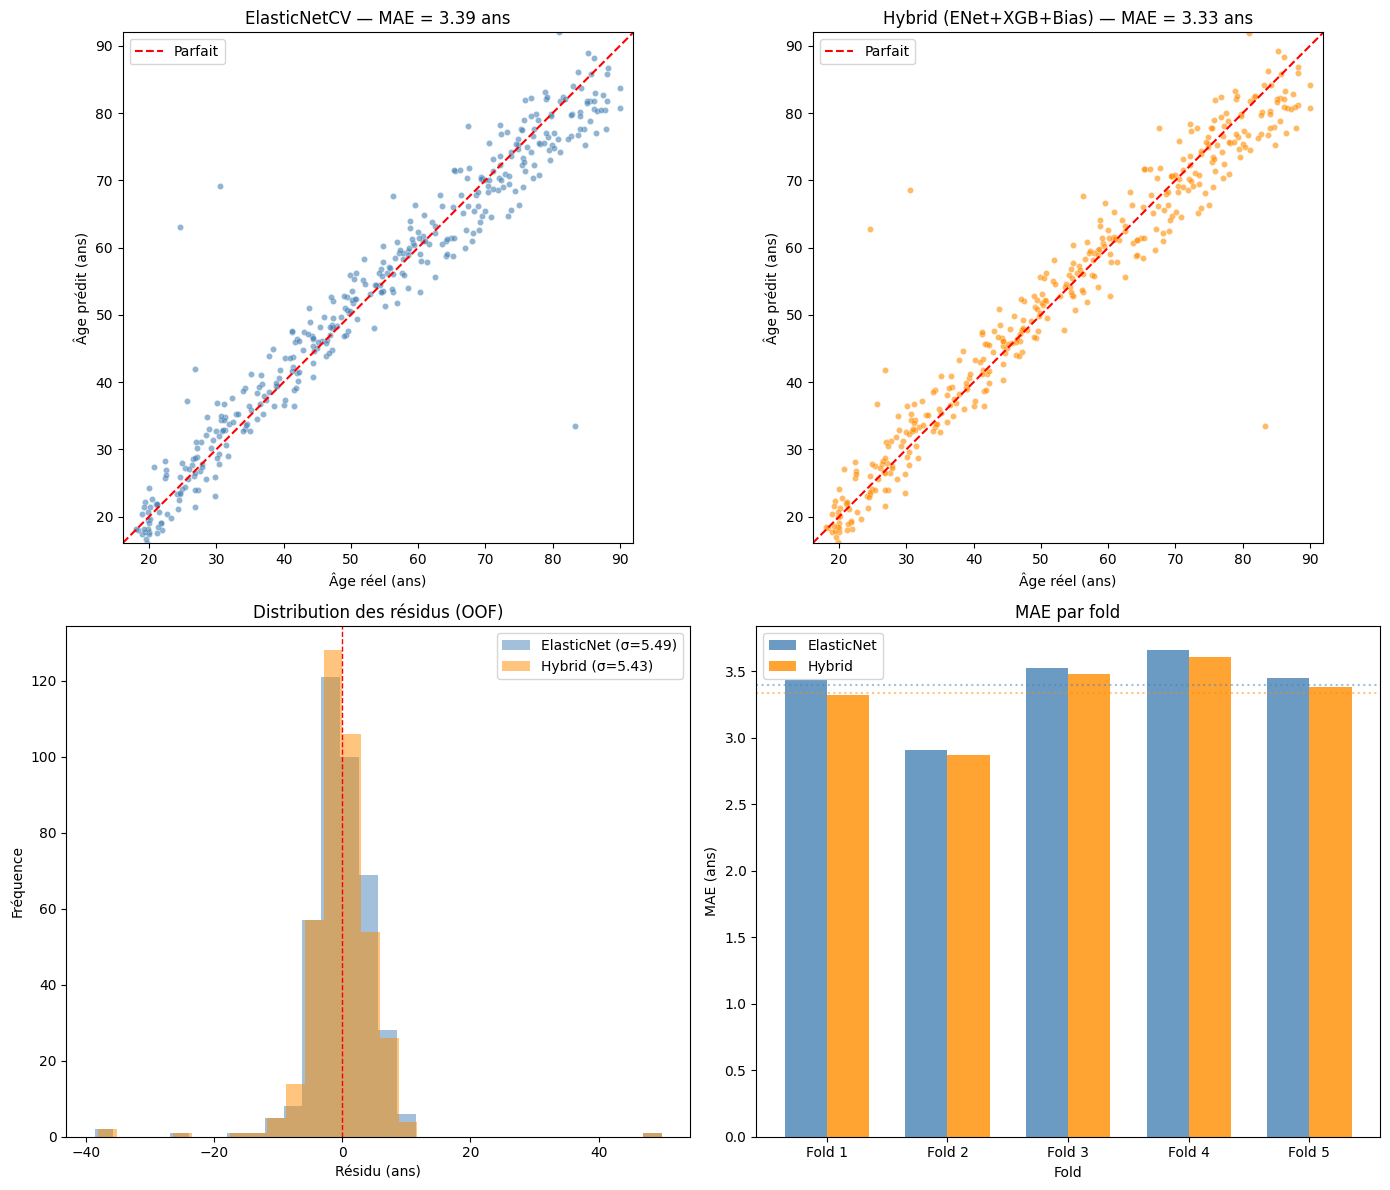

Figure sauvegardée : results/residual_learning_results.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- Plot 1 : Prédictions vs Réel (ElasticNet) ---
ax = axes[0, 0]
ax.scatter(y_all, oof_preds_enet, alpha=0.6, s=20, c="steelblue", edgecolors="white", linewidth=0.3)
lims = [y_all.min() - 2, y_all.max() + 2]
ax.plot(lims, lims, "--", color="red", linewidth=1.5, label="Parfait")
ax.set_xlabel("Âge réel (ans)")
ax.set_ylabel("Âge prédit (ans)")
ax.set_title(f"ElasticNetCV — MAE = {enet_mean_mae:.2f} ans")
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")

# --- Plot 2 : Prédictions vs Réel (Hybrid) ---
ax = axes[0, 1]
ax.scatter(y_all, oof_preds_hybrid, alpha=0.6, s=20, c="darkorange", edgecolors="white", linewidth=0.3)
ax.plot(lims, lims, "--", color="red", linewidth=1.5, label="Parfait")
ax.set_xlabel("Âge réel (ans)")
ax.set_ylabel("Âge prédit (ans)")
ax.set_title(f"Hybrid (ENet+XGB+Bias) — MAE = {hybrid_mean_mae:.2f} ans")
ax.legend()
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")

# --- Plot 3 : Distribution des résidus ---
ax = axes[1, 0]
residuals_enet = y_all - oof_preds_enet
residuals_hybrid = y_all - oof_preds_hybrid
ax.hist(residuals_enet, bins=30, alpha=0.5, label=f"ElasticNet (σ={np.std(residuals_enet):.2f})", color="steelblue")
ax.hist(residuals_hybrid, bins=30, alpha=0.5, label=f"Hybrid (σ={np.std(residuals_hybrid):.2f})", color="darkorange")
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Résidu (ans)")
ax.set_ylabel("Fréquence")
ax.set_title("Distribution des résidus (OOF)")
ax.legend()

# --- Plot 4 : Comparaison MAE par fold ---
ax = axes[1, 1]
x_pos = np.arange(N_OUTER_FOLDS)
width = 0.35
bars1 = ax.bar(x_pos - width/2, df_results["enet_mae"], width, label="ElasticNet", color="steelblue", alpha=0.8)
bars2 = ax.bar(x_pos + width/2, df_results["hybrid_mae"], width, label="Hybrid", color="darkorange", alpha=0.8)
ax.set_xlabel("Fold")
ax.set_ylabel("MAE (ans)")
ax.set_title("MAE par fold")
ax.set_xticks(x_pos)
ax.set_xticklabels([f"Fold {i+1}" for i in range(N_OUTER_FOLDS)])
ax.legend()
ax.axhline(enet_mean_mae, color="steelblue", linestyle=":", alpha=0.5)
ax.axhline(hybrid_mean_mae, color="darkorange", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("results/residual_learning_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : results/residual_learning_results.png")

## 7. Analyse du biais par groupe d'âge

Les modèles linéaires tendent à sous-estimer les sujets âgés et sur-estimer les jeunes. Vérifions si la correction de biais aide.

Analyse par groupe d'âge (OOF predictions) :
Groupe d'âge  N  Biais ENet  MAE ENet  Biais Hybrid  MAE Hybrid
       30-40 51        2.26      3.19          2.06        3.05
       40-50 59        1.23      2.45          0.96        2.32
       50-60 52        1.33      2.57          1.24        2.57
       60-70 49       -1.03      3.34         -0.95        3.42
         70+ 88       -1.91      4.19         -1.76        4.16


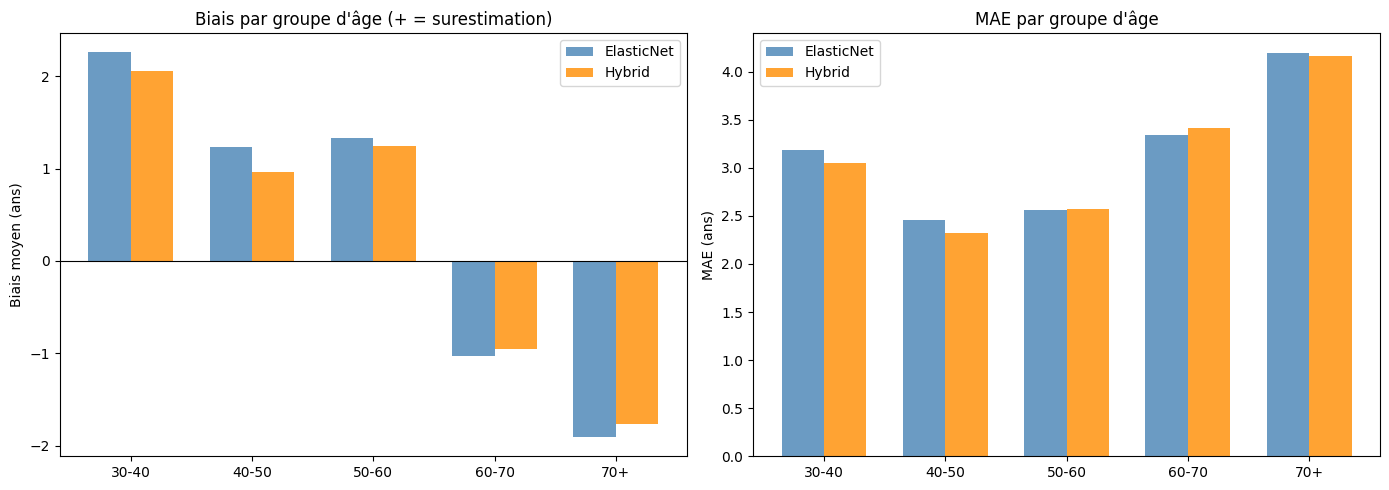

Figure sauvegardée : results/residual_learning_bias_analysis.png


In [8]:
# Analyse par groupe d'âge
age_bins = [30, 40, 50, 60, 70, 85]
age_labels = ["30-40", "40-50", "50-60", "60-70", "70+"]
age_groups = pd.cut(y_all, bins=age_bins, labels=age_labels)

bias_data = []
for group in age_labels:
    mask = age_groups == group
    n = mask.sum()
    if n == 0:
        continue
    
    # Biais = prédiction - réel (positif = surestimation)
    bias_enet = (oof_preds_enet[mask] - y_all[mask]).mean()
    bias_hybrid = (oof_preds_hybrid[mask] - y_all[mask]).mean()
    mae_enet = mean_absolute_error(y_all[mask], oof_preds_enet[mask])
    mae_hybrid = mean_absolute_error(y_all[mask], oof_preds_hybrid[mask])
    
    bias_data.append({
        "Groupe d'âge": group,
        "N": n,
        "Biais ENet": bias_enet,
        "MAE ENet": mae_enet,
        "Biais Hybrid": bias_hybrid,
        "MAE Hybrid": mae_hybrid,
    })

df_bias = pd.DataFrame(bias_data)
print("Analyse par groupe d'âge (OOF predictions) :")
print(df_bias.to_string(index=False, float_format="%.2f"))

# Plot biais
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x_pos = np.arange(len(df_bias))
width = 0.35
ax.bar(x_pos - width/2, df_bias["Biais ENet"], width, label="ElasticNet", color="steelblue", alpha=0.8)
ax.bar(x_pos + width/2, df_bias["Biais Hybrid"], width, label="Hybrid", color="darkorange", alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(df_bias["Groupe d'âge"])
ax.set_ylabel("Biais moyen (ans)")
ax.set_title("Biais par groupe d'âge (+ = surestimation)")
ax.legend()

ax = axes[1]
ax.bar(x_pos - width/2, df_bias["MAE ENet"], width, label="ElasticNet", color="steelblue", alpha=0.8)
ax.bar(x_pos + width/2, df_bias["MAE Hybrid"], width, label="Hybrid", color="darkorange", alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(df_bias["Groupe d'âge"])
ax.set_ylabel("MAE (ans)")
ax.set_title("MAE par groupe d'âge")
ax.legend()

plt.tight_layout()
plt.savefig("results/residual_learning_bias_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : results/residual_learning_bias_analysis.png")

## 8. Entraînement du modèle final (sur tout le dataset)

Maintenant que la nested CV a validé l'approche, on entraîne le modèle final sur **toutes les données** pour une utilisation en production.

In [9]:
print("Entraînement du modèle final sur les 400 échantillons...")
t0 = time()

final_pipeline = ResidualLearningPipeline(
    top_k=TOP_K,
    xgb_n_estimators=300,
    xgb_max_depth=3,
    xgb_learning_rate=0.03,
    xgb_subsample=0.7,
    xgb_colsample_bytree=0.5,
    xgb_reg_alpha=10.0,
    xgb_reg_lambda=50.0,
    xgb_min_child_weight=10,
    xgb_early_stopping_rounds=30,
)
final_pipeline.fit(X_full, y_all)

# Training metrics (indicatif — pas pour évaluation)
y_pred_final = final_pipeline.predict(X_full)
y_pred_enet_final = final_pipeline.predict_enet_only(X_full)

print(f"\nModèle final entraîné en {time() - t0:.1f}s")
print(f"  Train MAE (ENet)   : {mean_absolute_error(y_all, y_pred_enet_final):.3f} ans")
print(f"  Train MAE (Hybrid) : {mean_absolute_error(y_all, y_pred_final):.3f} ans")
print(f"  Info: {final_pipeline.get_info()}")

Entraînement du modèle final sur les 400 échantillons...

Modèle final entraîné en 433.2s
  Train MAE (ENet)   : 0.417 ans
  Train MAE (Hybrid) : 0.170 ans
  Info: {'enet_alpha': np.float64(0.19690655676160868), 'enet_l1_ratio': np.float64(0.1), 'enet_n_nonzero_coefs': np.int64(1621), 'xgb_best_iteration': 299, 'bias_w_lin': np.float32(0.9978703), 'bias_w_residual': np.float32(2.785332), 'bias_intercept': np.float32(0.14934158)}


In [10]:
# Sauvegarder le modèle final
import joblib

model_path = Path("results/models/residual_learning_pipeline.joblib")
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(final_pipeline, model_path)
print(f"Modèle sauvegardé : {model_path}")

# Sauvegarder les résultats CV
results_path = Path("results/residual_learning_cv_results.csv")
df_results.to_csv(results_path, index=False)
print(f"Résultats CV sauvegardés : {results_path}")

Modèle sauvegardé : results/models/residual_learning_pipeline.joblib
Résultats CV sauvegardés : results/residual_learning_cv_results.csv


## 9. Résumé

### Architecture
```
CpG features ──→ [ElasticNetCV] ──→ P_lin ──→ Résidus R = y - P_lin
                                                     │
CpG features ──→ [XGBoost] ──→ R_hat ───────────────┘
                                  │
              [P_lin, R_hat] ──→ [Linear Bias Correction] ──→ Prédiction finale
```

### Pourquoi ça marche
1. **ElasticNet** capture les relations linéaires (la majorité du signal)
2. **XGBoost** capture les interactions non-linéaires dans les résidus
3. **Bias Correction** compense la régression vers la moyenne (sous-estimation des extrêmes)

### Garde-fous anti-overfitting (N=400)
- ElasticNetCV avec cross-validation interne pour alpha/l1_ratio
- XGBoost : faible profondeur (3), forte régularisation (alpha=10, lambda=50), early stopping
- Feature selection **intra-fold** (pas de data leakage)
- Validation par nested CV (5 folds externes)

## 10. Validation du modèle sauvegardé (K-Fold 5) — MAE Test uniquement

Validation honnête : on **ré-entraîne un pipeline neuf** à chaque fold et on évalue **uniquement sur les données hors entraînement**.
Aucun sample du test n'a été vu pendant le fit.

  Validation 5-Fold — MAE Test (données hors entraînement)

  Fold 1  │  ENet MAE = 3.432  │  Hybrid MAE = 3.323  │  Δ = +0.109  │  76s
  Fold 2  │  ENet MAE = 2.905  │  Hybrid MAE = 2.868  │  Δ = +0.037  │  96s
  Fold 3  │  ENet MAE = 3.528  │  Hybrid MAE = 3.478  │  Δ = +0.050  │  74s
  Fold 4  │  ENet MAE = 3.657  │  Hybrid MAE = 3.609  │  Δ = +0.047  │  60s
  Fold 5  │  ENet MAE = 3.452  │  Hybrid MAE = 3.385  │  Δ = +0.067  │  65s

───────────────────────────────────────────────────────
  ElasticNet seul  :  MAE = 3.395 ± 0.257 ans
  Hybrid (E+X+B)   :  MAE = 3.333 ± 0.252 ans
  Gain moyen       :  +0.062 ans (+1.8%)
───────────────────────────────────────────────────────


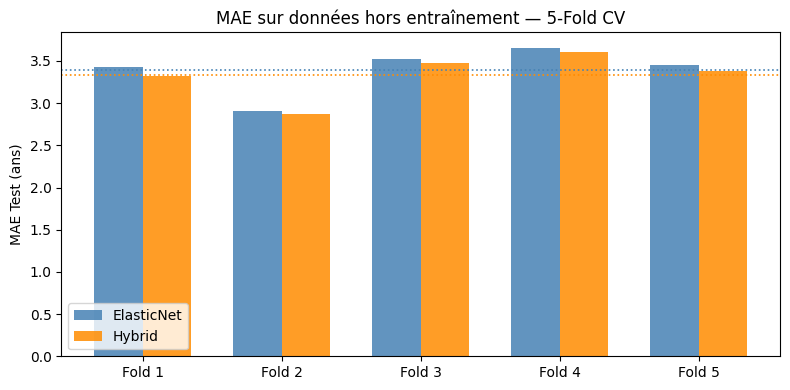

Figure sauvegardée : results/residual_learning_validation.png


In [12]:
N_VAL_FOLDS = 5
val_cv = KFold(n_splits=N_VAL_FOLDS, shuffle=True, random_state=RANDOM_STATE)

val_mae_enet = []
val_mae_hybrid = []

print(f"{'='*55}")
print(f"  Validation 5-Fold — MAE Test (données hors entraînement)")
print(f"{'='*55}\n")

for fold_i, (train_idx, test_idx) in enumerate(val_cv.split(X_full, y_all)):
    t0 = time()

    X_tr, X_te = X_full[train_idx], X_full[test_idx]
    y_tr, y_te = y_all[train_idx], y_all[test_idx]

    # Pipeline neuf, entraîné uniquement sur le train du fold
    pipe = ResidualLearningPipeline(
        top_k=TOP_K,
        xgb_n_estimators=300,
        xgb_max_depth=3,
        xgb_learning_rate=0.03,
        xgb_subsample=0.7,
        xgb_colsample_bytree=0.5,
        xgb_reg_alpha=10.0,
        xgb_reg_lambda=50.0,
        xgb_min_child_weight=10,
        xgb_early_stopping_rounds=30,
    )
    pipe.fit(X_tr, y_tr, X_val=X_te, y_val=y_te)

    # Prédictions sur le test (jamais vu pendant le fit)
    mae_enet = mean_absolute_error(y_te, pipe.predict_enet_only(X_te))
    mae_hybrid = mean_absolute_error(y_te, pipe.predict(X_te))

    val_mae_enet.append(mae_enet)
    val_mae_hybrid.append(mae_hybrid)

    delta = mae_enet - mae_hybrid
    print(f"  Fold {fold_i+1}  │  ENet MAE = {mae_enet:.3f}  │  "
          f"Hybrid MAE = {mae_hybrid:.3f}  │  Δ = {delta:+.3f}  │  {time()-t0:.0f}s")

# --- Résumé ---
mean_enet = np.mean(val_mae_enet)
std_enet = np.std(val_mae_enet)
mean_hyb = np.mean(val_mae_hybrid)
std_hyb = np.std(val_mae_hybrid)
delta_mean = mean_enet - mean_hyb

print(f"\n{'─'*55}")
print(f"  ElasticNet seul  :  MAE = {mean_enet:.3f} ± {std_enet:.3f} ans")
print(f"  Hybrid (E+X+B)   :  MAE = {mean_hyb:.3f} ± {std_hyb:.3f} ans")
print(f"  Gain moyen       :  {delta_mean:+.3f} ans ({delta_mean/mean_enet*100:+.1f}%)")
print(f"{'─'*55}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(N_VAL_FOLDS)
w = 0.35
ax.bar(x - w/2, val_mae_enet, w, label="ElasticNet", color="steelblue", alpha=0.85)
ax.bar(x + w/2, val_mae_hybrid, w, label="Hybrid", color="darkorange", alpha=0.85)
ax.axhline(mean_enet, color="steelblue", ls=":", lw=1.2)
ax.axhline(mean_hyb, color="darkorange", ls=":", lw=1.2)
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i+1}" for i in range(N_VAL_FOLDS)])
ax.set_ylabel("MAE Test (ans)")
ax.set_title("MAE sur données hors entraînement — 5-Fold CV")
ax.legend()
plt.tight_layout()
plt.savefig("results/residual_learning_validation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : results/residual_learning_validation.png")